In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

def plot_phase_space_4panel(
    x, xp, y, yp,
    filename="phase_space_4panel",
    save=True,
    units_already_mm_mrad=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(13, 10),
    plot_rms_ellipse=True,
    contain_fraction=0.90,
    ellipse_color="red",
    ellipse_lw=2.2,
    ellipse_label=True
):
    """
    Plotea en una figura 2x2:

        x  - x'
        y  - y'
        x  - y
        x' - y'

    Además, pinta la elipse RMS escalada para contener el 90% de las partículas
    en cada plano.

    Guarda el PDF en la carpeta actual.
    """

    x = np.asarray(x)
    xp = np.asarray(xp)
    y = np.asarray(y)
    yp = np.asarray(yp)

    if not units_already_mm_mrad:
        x = x * 1e3
        y = y * 1e3
        xp = xp * 1e3
        yp = yp * 1e3

    def rms_ellipse_90(a, b, contain_fraction=0.90, npoints=600):
        """
        Elipse RMS escalada para contener contain_fraction de las partículas.

        Se usa la matriz de covarianza RMS para la forma y orientación.
        El tamaño se escala con la distancia de Mahalanobis empírica,
        de forma que encierre realmente el porcentaje indicado.
        """

        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        if len(a) < 3:
            return None, None

        q = np.column_stack([a, b])
        mean = np.mean(q, axis=0)
        q0 = q - mean

        Sigma = np.cov(q0.T, bias=True)

        # Evitar problemas si la matriz es casi singular
        try:
            Sigma_inv = np.linalg.inv(Sigma)
        except np.linalg.LinAlgError:
            Sigma_inv = np.linalg.pinv(Sigma)

        d2 = np.einsum("ij,jk,ik->i", q0, Sigma_inv, q0)

        if not np.all(np.isfinite(d2)):
            return None, None

        scale = np.sqrt(np.quantile(d2, contain_fraction))

        eigvals, eigvecs = np.linalg.eigh(Sigma)

        # Protección frente a autovalores negativos numéricos
        eigvals = np.maximum(eigvals, 0.0)

        theta = np.linspace(0, 2*np.pi, npoints)
        circle = np.vstack([np.cos(theta), np.sin(theta)])

        ellipse = mean[:, None] + scale * eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

        return ellipse[0], ellipse[1]

    def density_scatter(ax, a, b, xlabel, ylabel):
        a = np.asarray(a)
        b = np.asarray(b)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        xy = np.vstack([a, b])

        try:
            kde = gaussian_kde(xy, bw_method=bw_method)
            z = kde(xy)

            idx = z.argsort()
            a_plot = a[idx]
            b_plot = b[idx]
            z_plot = z[idx]

            sc = ax.scatter(
                a_plot, b_plot,
                c=z_plot,
                s=point_size,
                cmap=cmap,
                alpha=alpha,
                edgecolors="none"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)

        except Exception:
            ax.scatter(
                a, b,
                s=point_size,
                alpha=alpha,
                edgecolors="none"
            )

        if plot_rms_ellipse:
            ex, ey = rms_ellipse_90(
                a,
                b,
                contain_fraction=contain_fraction
            )

            if ex is not None:
                label = f"{int(contain_fraction*100)}%-ellipse" if ellipse_label else None
                ax.plot(
                    ex, ey,
                    color=ellipse_color,
                    lw=ellipse_lw,
                    label=label
                )

                if ellipse_label:
                    ax.legend(fontsize=tick_fontsize, loc="best")

        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    density_scatter(axs[0, 0], x, xp, r"$x$ [mm]", r"$x'$ [mrad]")
    density_scatter(axs[0, 1], y, yp, r"$y$ [mm]", r"$y'$ [mrad]")
    density_scatter(axs[1, 0], x, y, r"$x$ [mm]", r"$y$ [mm]")
    density_scatter(axs[1, 1], xp, yp, r"$x'$ [mrad]", r"$y'$ [mrad]")

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()

def plot_phase_space_4panel_remix(
    x, xp, y, yp,
    filename="phase_space_4panel",
    save=True,
    units_already_mm_mrad=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(13, 10),

    # Elipses
    plot_rms_normal=True,
    plot_rms_90=True,
    contain_fraction=0.90,
    rms_normal_color="black",
    rms_90_color="red",
    rms_normal_lw=2.0,
    rms_90_lw=2.2,
    rms_normal_ls="--",
    rms_90_ls="-",
    show_legend=True
):
    """
    Plotea en una figura 2x2:

        x  - x'
        y  - y'
        x  - y
        x' - y'

    Además pinta:
        - Elipse RMS normal, escala 1 sigma RMS.
        - Elipse RMS escalada al 90% de partículas.
    """

    x = np.asarray(x)
    xp = np.asarray(xp)
    y = np.asarray(y)
    yp = np.asarray(yp)

    if not units_already_mm_mrad:
        x = x * 1e3
        y = y * 1e3
        xp = xp * 1e3
        yp = yp * 1e3

    def rms_ellipse(a, b, scale=1.0, npoints=600):
        """
        Elipse RMS usando matriz de covarianza.

        scale = 1.0 -> elipse RMS normal.
        scale > 1  -> elipse escalada.
        """

        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        if len(a) < 3:
            return None, None

        q = np.column_stack([a, b])
        mean = np.mean(q, axis=0)
        q0 = q - mean

        Sigma = np.cov(q0.T, bias=True)

        eigvals, eigvecs = np.linalg.eigh(Sigma)
        eigvals = np.maximum(eigvals, 0.0)

        theta = np.linspace(0, 2*np.pi, npoints)
        circle = np.vstack([np.cos(theta), np.sin(theta)])

        ellipse = mean[:, None] + scale * eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

        return ellipse[0], ellipse[1]

    def scale_for_fraction(a, b, contain_fraction=0.90):
        """
        Calcula el factor de escala de la elipse RMS para contener
        contain_fraction de las partículas usando Mahalanobis.
        """

        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        if len(a) < 3:
            return None

        q = np.column_stack([a, b])
        mean = np.mean(q, axis=0)
        q0 = q - mean

        Sigma = np.cov(q0.T, bias=True)

        try:
            Sigma_inv = np.linalg.inv(Sigma)
        except np.linalg.LinAlgError:
            Sigma_inv = np.linalg.pinv(Sigma)

        d2 = np.einsum("ij,jk,ik->i", q0, Sigma_inv, q0)

        if not np.all(np.isfinite(d2)):
            return None

        scale = np.sqrt(np.quantile(d2, contain_fraction))

        return scale

    def density_scatter(ax, a, b, xlabel, ylabel):
        a = np.asarray(a)
        b = np.asarray(b)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        xy = np.vstack([a, b])

        try:
            kde = gaussian_kde(xy, bw_method=bw_method)
            z = kde(xy)

            idx = z.argsort()
            a_plot = a[idx]
            b_plot = b[idx]
            z_plot = z[idx]

            sc = ax.scatter(
                a_plot, b_plot,
                c=z_plot,
                s=point_size,
                cmap=cmap,
                alpha=alpha,
                edgecolors="none"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)

        except Exception:
            ax.scatter(
                a, b,
                s=point_size,
                alpha=alpha,
                edgecolors="none"
            )

        # -----------------------------
        # Elipse RMS normal
        # -----------------------------
        if plot_rms_normal:
            ex, ey = rms_ellipse(a, b, scale=1.0)

            if ex is not None:
                ax.plot(
                    ex, ey,
                    color=rms_normal_color,
                    lw=rms_normal_lw,
                    ls=rms_normal_ls,
                    label="RMS"
                )

        # -----------------------------
        # Elipse RMS 90%
        # -----------------------------
        if plot_rms_90:
            scale_90 = scale_for_fraction(
                a,
                b,
                contain_fraction=contain_fraction
            )

            if scale_90 is not None:
                ex90, ey90 = rms_ellipse(a, b, scale=scale_90)

                if ex90 is not None:
                    ax.plot(
                        ex90, ey90,
                        color=rms_90_color,
                        lw=rms_90_lw,
                        ls=rms_90_ls,
                        label=f"RMS {int(contain_fraction*100)}%"
                    )

        if show_legend and (plot_rms_normal or plot_rms_90):
            ax.legend(fontsize=tick_fontsize, loc="best")

        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    density_scatter(axs[0, 0], x, xp, r"$x$ [mm]", r"$x'$ [mrad]")
    density_scatter(axs[0, 1], y, yp, r"$y$ [mm]", r"$y'$ [mrad]")
    density_scatter(axs[1, 0], x, y, r"$x$ [mm]", r"$y$ [mm]")
    density_scatter(axs[1, 1], xp, yp, r"$x'$ [mrad]", r"$y'$ [mrad]")

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Guardado en: /home/guest/tfm_pedro/Validation-of-linear-ion-accelerator/Tracewin/phase_space_final.pdf


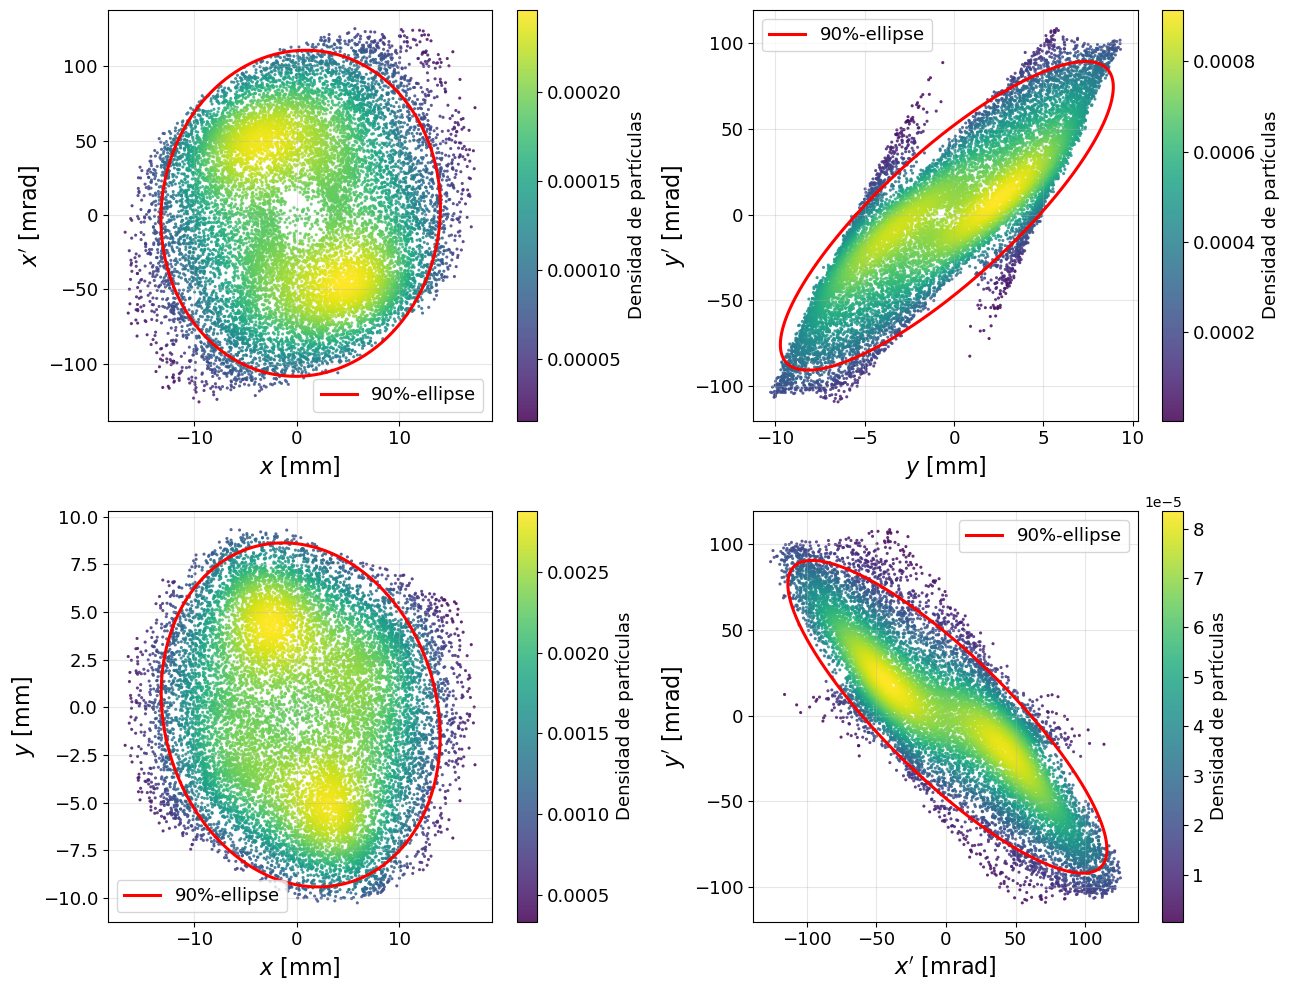

In [6]:
data = np.loadtxt("output_lebt_tracewin_noSC.txt", skiprows=1)

x    = data[:, 0] * 10    # cm -> mm
xp   = data[:, 1]   #  mrad
y    = data[:, 2] * 10    # cm -> mm
yp   = data[:, 3]    #  mrad
loss = data[:, 9]         # 0 = viva, 1 = perdida

# Filtrar solo partículas vivas
mask_alive = loss == 0

x  = x[mask_alive]
xp = xp[mask_alive]
y  = y[mask_alive]
yp = yp[mask_alive]
loss = loss[mask_alive]

plot_phase_space_4panel(
    x=x,
    xp=xp,
    y=y,
    yp=yp,
    filename="phase_space_final",
)